
# Linear Regression

<a target="_blank" href="https://colab.research.google.com/github/intro-stat-learning/ISLP_labs/blob/v2.2/Ch03-linreg-lab.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/intro-stat-learning/ISLP_labs/v2.2?labpath=Ch03-linreg-lab.ipynb)


## Importing packages
We import our standard libraries at this top
level.

In [92]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots


### New imports
Throughout this lab we will introduce new functions and libraries. However,
we will import them here to emphasize these are the new
code objects in this lab. Keeping imports near the top
of a notebook makes the code more readable, since scanning the first few
lines tells us what libraries are used.

In [93]:
import statsmodels.api as sm


 We will provide relevant details about the
functions below as they are needed.

Besides importing whole modules, it is also possible
to import only a few items from a given module. This
will help keep the  *namespace* clean.
We will use a few specific objects from the `statsmodels` package
which we import here.

In [94]:
from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm


In [26]:
%pip install ISLP

^C
Note: you may need to restart the kernel to use updated packages.


As one of the import statements above is quite a long line, we inserted a line break `\` to
ease readability.

We will also use some functions written for the labs in this book in the `ISLP`
package.

In [95]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)


### Inspecting Objects and Namespaces
The
function  `dir()`
provides a list of
objects in a namespace.

In [ ]:
dir()


['In',
 'MS',
 'Out',
 'VIF',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_exit_code',
 '_i',
 '_i1',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'anova_lm',
 'exit',
 'get_ipython',
 'load_data',
 'np',
 'open',
 'pd',
 'poly',
 'quit',
 'sm',
 'subplots',
 'summarize']

 This shows you everything that `Python` can find at the top level.
There are certain objects like `__builtins__` that contain references to built-in
functions like `print()`.

Every python object has its own notion of
namespace, also accessible with `dir()`. This will include
both the attributes of the object
as well as any methods associated with it. For instance, we see `'sum'` in the listing for an
array.

In [ ]:
A = np.array([3,5,11])
dir(A)


['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',


 This indicates that the object `A.sum` exists. In this case it is a method
that can be used to compute the sum of the array `A` as can be seen by typing `A.sum?`.

In [ ]:
A.sum()


np.int64(19)

## Simple Linear Regression
In this section we will  construct model 
matrices (also called design matrices) using the `ModelSpec()`  transform from `ISLP.models`.

We  will use the `Boston` housing data set, which is contained in the `ISLP` package.  The `Boston` dataset records  `medv`  (median house value) for $506$ neighborhoods
around Boston.  We will build a regression model to predict  `medv`  using $13$
predictors such as  `rmvar`  (average number of rooms per house),
 `age`  (proportion of owner-occupied units built prior to 1940), and  `lstat`  (percent of
households with low socioeconomic status).  We will use `statsmodels` for this
task, a `Python` package that implements several commonly used
regression methods.

We have included a simple loading function `load_data()` in the
`ISLP` package:

In [28]:
Boston = load_data("Boston")
Boston.columns


Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\ssark\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


Type `Boston?` to find out more about these data.

We start by using the `sm.OLS()`  function to fit a
simple linear regression model.  Our response will be
 `medv`  and  `lstat`  will be the single predictor.
For this model, we can create the model matrix by hand.


In [ ]:
X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]),
                  'lstat': Boston['lstat']})
X[:4]


,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


We extract the response, and fit the model.

In [ ]:
y = Boston['medv']
model = sm.OLS(y, X)
results = model.fit()


Note that `sm.OLS()` does
not fit the model; it specifies the model, and then `model.fit()` does the actual fitting.  

Our `ISLP` function `summarize()` produces a simple table of the parameter estimates,
their standard errors, t-statistics and p-values.
The function takes a single argument, such as the object `results` 
returned here by the `fit`
method, and returns such a summary.

In [ ]:
summarize(results)


,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


Before we describe other methods for working with fitted models, we outline a more useful and general framework for constructing a model matrix~`X`.
### Using Transformations: Fit and Transform
Our model above has a single predictor, and constructing `X` was straightforward. 
In practice  we often fit models with more than one predictor, typically selected from an array or data frame.
We may wish to introduce transformations to the variables before fitting the model, specify interactions between variables, and expand some particular variables into sets of variables (e.g. polynomials).
The `sklearn`  package has a particular notion
for this type of task: a *transform*. A transform is an object
that is created with some parameters as arguments. The
object has two main methods: `fit()` and `transform()`.

We provide a general approach for specifying models and constructing
the model matrix through the transform `ModelSpec()` in the `ISLP` library.
`ModelSpec()`
(renamed `MS()` in the preamble) creates a
transform object, and then a pair of methods
`transform()` and `fit()` are used to construct a
corresponding model matrix.

We first describe this process for our simple regression model  using a single predictor `lstat` in
the `Boston` data frame, but will use it repeatedly in more
complex tasks in this and other labs in this book.
In our case the transform is created by the expression
`design = MS(['lstat'])`.

The `fit()`  method takes the original array and may do some
initial computations on it, as specified in the transform object.
For example, it may compute means and standard deviations for centering and scaling.
The `transform()` 
method applies the fitted transformation to the array of data, and produces the model matrix.


In [ ]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In this simple case, the `fit()`  method does very little; it simply checks that the variable `'lstat'` specified in `design` exists in `Boston`. Then `transform()` constructs the model matrix with two columns: an `intercept` and the variable `lstat`.

These two operations can be  combined with the
`fit_transform()`  method.

In [ ]:
design = MS(['lstat'])
X = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


Note that, as in the previous code chunk when the two steps were done separately, the `design` object is changed as a result of the `fit()` operation. The power of this pipeline will become clearer when we fit more complex models that involve interactions and transformations.

Let's return to our fitted regression model.
The object
`results` has several methods that can be used for inference.
We already presented a function `summarize()` for showing the essentials of the fit.
For a full and somewhat exhaustive summary of the fit, we can use the `summary()` 
method.

In [ ]:
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Mon, 18 May 2026   Prob (F-statistic):           5.08e-88
Time:                        16:51:17   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The fitted coefficients can also be retrieved as the
`params` attribute of `results`.

In [ ]:
results.params


intercept    34.553841
lstat        -0.950049
dtype: float64

The `get_prediction()`  method can be used to obtain predictions, and produce confidence intervals and
prediction intervals for the prediction of  `medv`  for  given values of  `lstat`.

We first create a new data frame, in this case containing only the variable `lstat`, with the values for this variable at which we wish to make predictions.
We then use the `transform()` method of `design` to create the corresponding model matrix.

In [ ]:
new_df = pd.DataFrame({'lstat':[5, 10, 15]})
newX = design.transform(new_df)
newX


,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


Next we compute the predictions at `newX`, and view them by extracting the `predicted_mean` attribute.

In [ ]:
new_predictions = results.get_prediction(newX);
new_predictions.predicted_mean


array([29.80359411, 25.05334734, 20.30310057])

We can produce confidence intervals for the predicted values.

In [ ]:
new_predictions.conf_int(alpha=0.05)


array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

Prediction intervals are computing by setting `obs=True`:

In [ ]:
new_predictions.conf_int(obs=True, alpha=0.05)


array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

 For instance, the 95% confidence interval associated with an
 `lstat`  value of 10 is (24.47, 25.63), and the 95% prediction
interval is (12.82, 37.28).  As expected, the confidence and
prediction intervals are centered around the same point (a predicted
value of 25.05 for  `medv`  when  `lstat`  equals
10), but the latter are substantially wider.

Next we will plot  `medv`  and  `lstat` 
using `DataFrame.plot.scatter()`, \definelongblankMR{plot.scatter()}{plot.slashslashscatter()}
and wish to
add the regression line to the resulting plot.

### Defining Functions
While there is a function
within the `ISLP` package that adds a line to an existing plot, we take this opportunity
to define our first function to do so.

In [96]:
def abline(ax, b, m):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim)


 A few things are illustrated above. First we see the syntax for defining a function:
`def funcname(...)`. The function has arguments `ax, b, m`
where `ax` is an axis object for an exisiting plot, `b` is the intercept and
`m` is the slope of the desired line. Other plotting  options can be passed on to
`ax.plot` by including additional optional arguments as follows:

In [97]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)


The addition of `*args` allows any number of
non-named arguments to `abline`, while `*kwargs` allows any
number of named arguments (such as `linewidth=3`) to `abline`.
In our function, we pass
these arguments verbatim to `ax.plot` above. Readers
interested in learning more about
functions are referred to the section on
defining functions in [docs.python.org/tutorial](https://docs.python.org/3/tutorial/controlflow.html#defining-functions).

Let’s use our new function to add this regression line to a plot of
`medv` vs. `lstat`.

C:\Users\ssark\AppData\Local\Temp\ipykernel_40544\4269803003.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0],
C:\Users\ssark\AppData\Local\Temp\ipykernel_40544\4269803003.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[1],


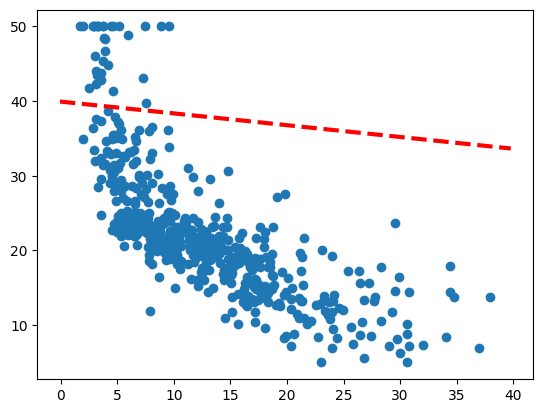

In [37]:
fig,ax=subplots()
ax.scatter(Boston['lstat'], Boston['medv'])
abline(ax,
       results.params[0],
       results.params[1],
       'r--',
       linewidth=3)


Thus, the final call to `ax.plot()` is `ax.plot(xlim, ylim, 'r--', linewidth=3)`.
We have used the argument `'r--'` to produce a red dashed line, and added
an argument to make it of width 3.
There is some evidence for non-linearity in the relationship between  `lstat`  and  `medv`. We will explore this issue later in this lab.

As mentioned above, there is an existing function to add a line to a plot --- `ax.axline()` --- but knowing how to write such functions empowers us to create more expressive displays.



Next we examine some diagnostic plots, several of which were discussed
in Section~\ref{Ch3:problems.sec}.
We can find the fitted values and residuals
of the fit as attributes of the `results` object.
Various influence measures describing the regression model
are computed with the `get_influence()` method.
As we will not use the `fig` component returned
as the first value from `subplots()`, we simply
capture the second returned value in `ax` below.

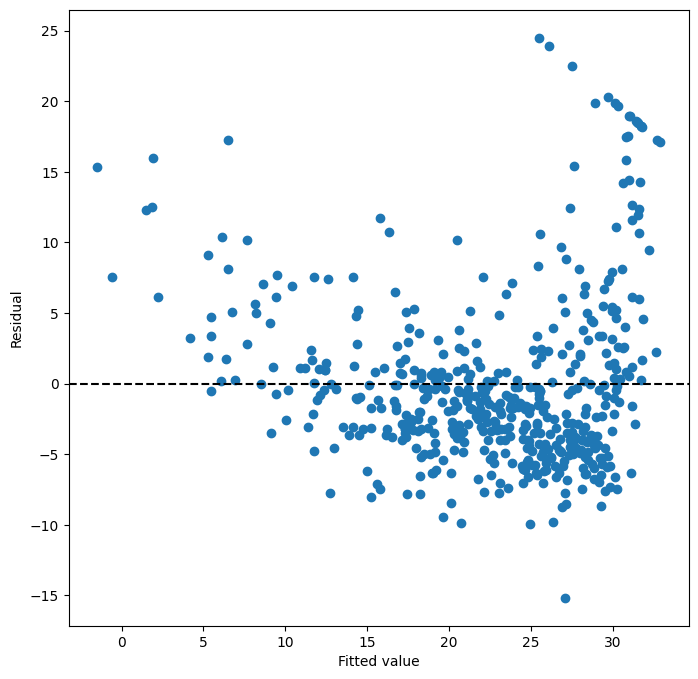

In [ ]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');


 We add a horizontal line at 0 for reference using the
 `ax.axhline()`   method, indicating
it should be black (`c='k'`) and have a dashed linestyle (`ls='--'`).

On the basis of the residual plot, there is some evidence of non-linearity.
Leverage statistics can be computed for any number of predictors using the
`hat_matrix_diag` attribute of the value returned by the
`get_influence()`  method.

np.int64(374)

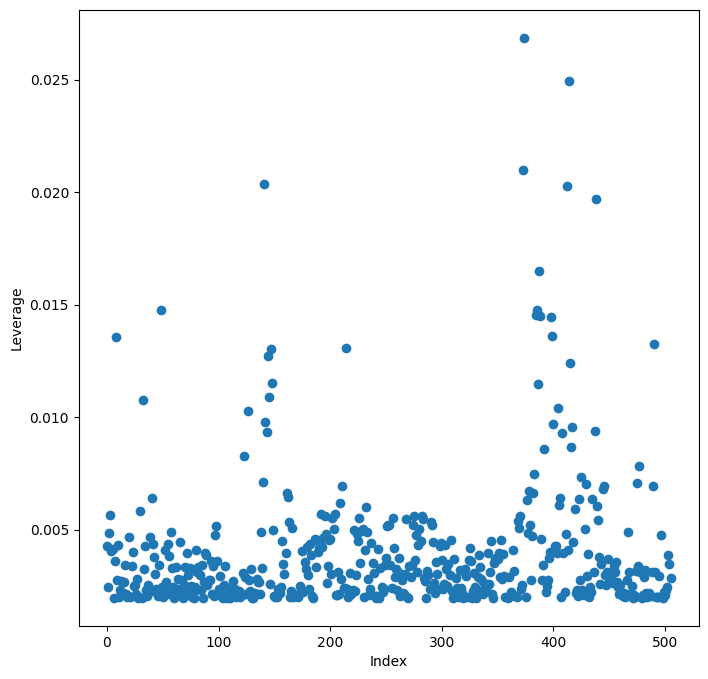

In [ ]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)


 The `np.argmax()`  function identifies the index of the largest element of an array, optionally computed over an axis of the array.
In this case, we maximized over the entire array
to determine which observation has the largest leverage statistic.

## Multiple Linear Regression
In order to fit a multiple linear regression model using least squares, we again use
the `ModelSpec()`  transform to construct the required
model matrix and response. The arguments
to `ModelSpec()` can be quite general, but in this case
a list of column names suffice. We consider a fit here with
the two variables `lstat` and `age`.

In [ ]:
X = MS(['lstat', 'age']).fit_transform(Boston)
model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


Notice how we have compacted the first line into a succinct expression describing the construction of `X`.

The  `Boston`   data set contains 12 variables, and so it would be cumbersome
to have to type all of these in order to perform a regression using all of the predictors.
Instead, we can use the following short-hand:\definelongblankMR{columns.drop()}{columns.slashslashdrop()}

In [ ]:
terms = Boston.columns.drop('medv')
terms


Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

We can now fit the model with all the variables in `terms` using
the same model matrix builder.

In [ ]:
X = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)


,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


What if we would like to perform a regression using all of the variables but one?  For
example, in the above regression output,   `age`  has a high $p$-value.
So we may wish to run a regression excluding this predictor.
The following syntax results in a regression using all predictors except  `age`.

In [ ]:
minus_age = Boston.columns.drop(['medv', 'age']) 
Xma = MS(minus_age).fit_transform(Boston)
model1 = sm.OLS(y, Xma)
summarize(model1.fit())


,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


## Multivariate Goodness of Fit
We can access the individual components of `results` by name
(`dir(results)` shows us what is available). Hence
`results.rsquared` gives us the $R^2$,
and
`np.sqrt(results.scale)` gives us the RSE.

Variance inflation factors (section~\ref{Ch3:problems.sec}) are sometimes useful
to assess the effect of collinearity in the model matrix of a regression model.
We will compute the VIFs in our multiple regression fit, and use the opportunity to introduce the idea of *list comprehension*.

### List Comprehension
Often we encounter a sequence of objects which we would like to transform
for some other task. Below, we compute the VIF for each
feature in our `X` matrix and produce a data frame
whose index agrees with the columns of `X`.
The notion of list comprehension can often make such
a task easier.

List comprehensions are simple and powerful ways to form
lists of `Python` objects. The language also supports
dictionary and *generator* comprehension, though these are
beyond our scope here. Let's look at an example. We compute the VIF for each of the variables
in the model matrix `X`, using the function `variance_inflation_factor()`.


In [ ]:
vals = [VIF(X, i)
        for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif':vals},
                   index=X.columns[1:])
vif


,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


The function `VIF()` takes two arguments: a dataframe or array,
and a variable column index. In the code above we call `VIF()` on the fly for all columns in `X`.  
We have excluded column 0 above (the intercept), which is not of interest. In this case the VIFs are not that exciting.

The object `vals` above could have been constructed with the following for loop:

In [ ]:
vals = []
for i in range(1, X.values.shape[1]):
    vals.append(VIF(X.values, i))


List comprehension allows us to perform such repetitive operations in a more straightforward way.
## Interaction Terms
It is easy to include interaction terms in a linear model using `ModelSpec()`.
Including a tuple `("lstat","age")` tells the model
matrix builder to include an interaction term between
 `lstat`  and  `age`.

In [ ]:
X = MS(['lstat',
        'age',
        ('lstat', 'age')]).fit_transform(Boston)
model2 = sm.OLS(y, X)
summarize(model2.fit())


,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


## Non-linear Transformations of the Predictors
The model matrix builder can include terms beyond
just column names and interactions. For instance,
the `poly()` function supplied in `ISLP` specifies that
columns representing polynomial functions
of its first argument are added to the model matrix.

In [ ]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)


,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


The effectively zero *p*-value associated with the quadratic term
(i.e. the third row above) suggests that it leads to an improved model.

By default, `poly()` creates a basis matrix for inclusion in the
model matrix whose
columns are *orthogonal polynomials*, which are designed for stable
least squares computations. {Actually, `poly()` is a  wrapper for the workhorse and standalone  function `Poly()` that does the  work in building the model matrix.}
Alternatively, had we included an argument
`raw=True` in the above call to `poly()`, the basis matrix would consist simply of
`lstat` and `lstat**2`. Since either of these bases
represent quadratic polynomials, the fitted values  would not
change in this case, just the polynomial coefficients.  Also by default, the columns
created by `poly()` do not include an intercept column as
that is automatically added by `MS()`.

We use the `anova_lm()` function to further quantify the extent to which the quadratic fit is
superior to the linear fit.

In [ ]:
anova_lm(results1, results3)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


Here `results1` represents the linear submodel containing
predictors `lstat` and `age`,
while `results3` corresponds to the larger model above  with a quadratic
term in `lstat`.
The `anova_lm()` function performs a hypothesis test
comparing the two models. The null hypothesis is that the quadratic
term in the bigger model is not needed, and the alternative hypothesis is that the
bigger model is superior. Here the *F*-statistic is 177.28 and
the associated *p*-value is zero.
In this case the *F*-statistic is the square of the
*t*-statistic for the quadratic term in the linear model summary
for `results3` --- a consequence of the fact that these nested
models differ by one degree of freedom.
This provides very clear evidence that the quadratic polynomial in
`lstat` improves the linear model.
This is not surprising, since earlier we saw evidence for non-linearity in the relationship between `medv`
and  `lstat`.

The function `anova_lm()` can take more than two nested models
as input, in which case it compares every successive pair of models.
That also explains why their are `NaN`s in the first row above, since
there is no previous model with which to compare the first.


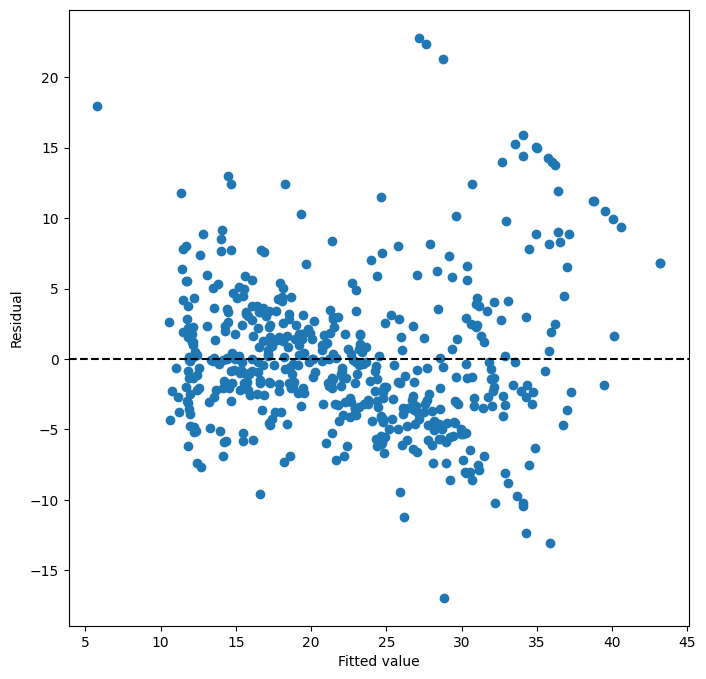

In [ ]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');


We see that when the quadratic term is included in the model,
there is little discernible pattern in the residuals.
In order to create a cubic or higher-degree polynomial fit, we can simply change the degree argument
to `poly()`.


## Qualitative Predictors
Here we use the  `Carseats`  data, which is included in the
`ISLP` package. We will  attempt to predict `Sales`
(child car seat sales) in 400 locations based on a number of
predictors.

In [ ]:
Carseats = load_data('Carseats')
Carseats.columns


Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

The `Carseats`  
 data includes qualitative predictors such as
 `ShelveLoc`, an indicator of the quality of the shelving
 location --- that is,
the  space within a store in which the car seat is displayed. The predictor
 `ShelveLoc`  takes on three possible values, `Bad`, `Medium`, and `Good`.
Given a qualitative variable such as  `ShelveLoc`, `ModelSpec()` generates dummy
variables automatically.
These variables are often referred to as a *one-hot encoding* of the categorical
feature. Their columns sum to one, so to avoid collinearity with an intercept, the first column is dropped. Below we see
the column `ShelveLoc[Bad]` has been dropped, since `Bad` is the first level of `ShelveLoc`.
Below we fit a multiple regression model that includes some interaction terms.

In [ ]:
allvars = list(Carseats.columns.drop('Sales'))
y = Carseats['Sales']
final = allvars + [('Income', 'Advertising'),
                   ('Price', 'Age')]
X = MS(final).fit_transform(Carseats)
model = sm.OLS(y, X)
summarize(model.fit())


NameError: name 'Carseats' is not defined

In [ ]:
num = 50 + 20*4 + 0.07*110 + 35 + 0.01*(4*110) - 10*4
print(num)

137.1


In [ ]:
# 8. This question involves the use of simple linear regression on the Auto
# data set.
# (a) Use the lm() function to perform a simple linear regression with
# mpg as the response and horsepower as the predictor. Use the
# summary() function to print the results. Comment on the output.
# For example:
# i. Is there a relationship between the predictor and the response?
# ii. How strong is the relationship between the predictor and
# the response?
# iii. Is the relationship between the predictor and the response
# positive or negative?
# iv. What is the predicted mpg associated with a horsepower of
# 98? What are the associated 95 % confidence and prediction
# intervals?

In [29]:
Data = load_data("Auto")
Data.columns


Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [30]:
design=MS(['horsepower'])
x=design.fit_transform(Data)
y=Data['mpg']
model=sm.OLS(y,x)
results=model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


In [31]:
predicted=results.get_prediction([1,98])
prediction=predicted.predicted_mean
conf=predicted.conf_int(alpha=.05)
pred=predicted.conf_int(obs=True,alpha=.05)

print(f"Predicted mpg is {prediction}, 95% Confidence Interval is {conf} and 95% Prediction Interval is {pred}")

Predicted mpg is [24.46707715], 95% Confidence Interval is [[23.97307896 24.96107534]] and 95% Prediction Interval is [[14.80939607 34.12475823]]


In [39]:
results.params

intercept     39.935861
horsepower    -0.157845
dtype: float64

C:\Users\ssark\AppData\Local\Temp\ipykernel_40544\3975675146.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0],
C:\Users\ssark\AppData\Local\Temp\ipykernel_40544\3975675146.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[1],


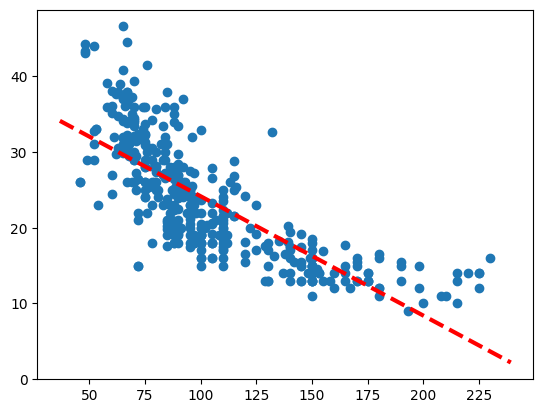

In [38]:
fig,ax=subplots()
ax.scatter(x['horsepower'],y)
abline(ax,
       results.params[0],
       results.params[1],
       'r--',
       linewidth=3)



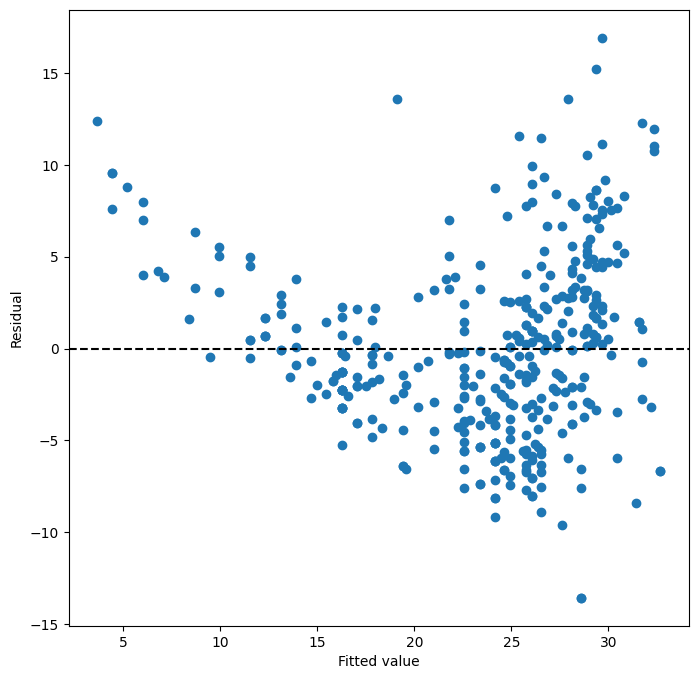

In [40]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

In [ ]:
# 9. This question involves the use of multiple linear regression on the
# Auto data set.
# (a) Produce a scatterplot matrix which includes all of the variables
# in the data set.
# (b) Compute the matrix of correlations between the variables using
# the function cor(). You will need to exclude the name variable, cor() which is qualitative.
# (c) Use the lm() function to perform a multiple linear regression
# with mpg as the response and all other variables except name as
# the predictors. Use the summary() function to print the results.
# Comment on the output. For instance:
# i. Is there a relationship between the predictors and the response?
# ii. Which predictors appear to have a statistically significant
# relationship to the response?
# iii. What does the coefficient for the year variable suggest?
# (d) Use the plot() function to produce diagnostic plots of the linear
# regression fit. Comment on any problems you see with the fit.
# Do the residual plots suggest any unusually large outliers? Does
# the leverage plot identify any observations with unusually high
# leverage?
# (e) Use the * and : symbols to fit linear regression models with
# interaction effects. Do any interactions appear to be statistically
# significant?

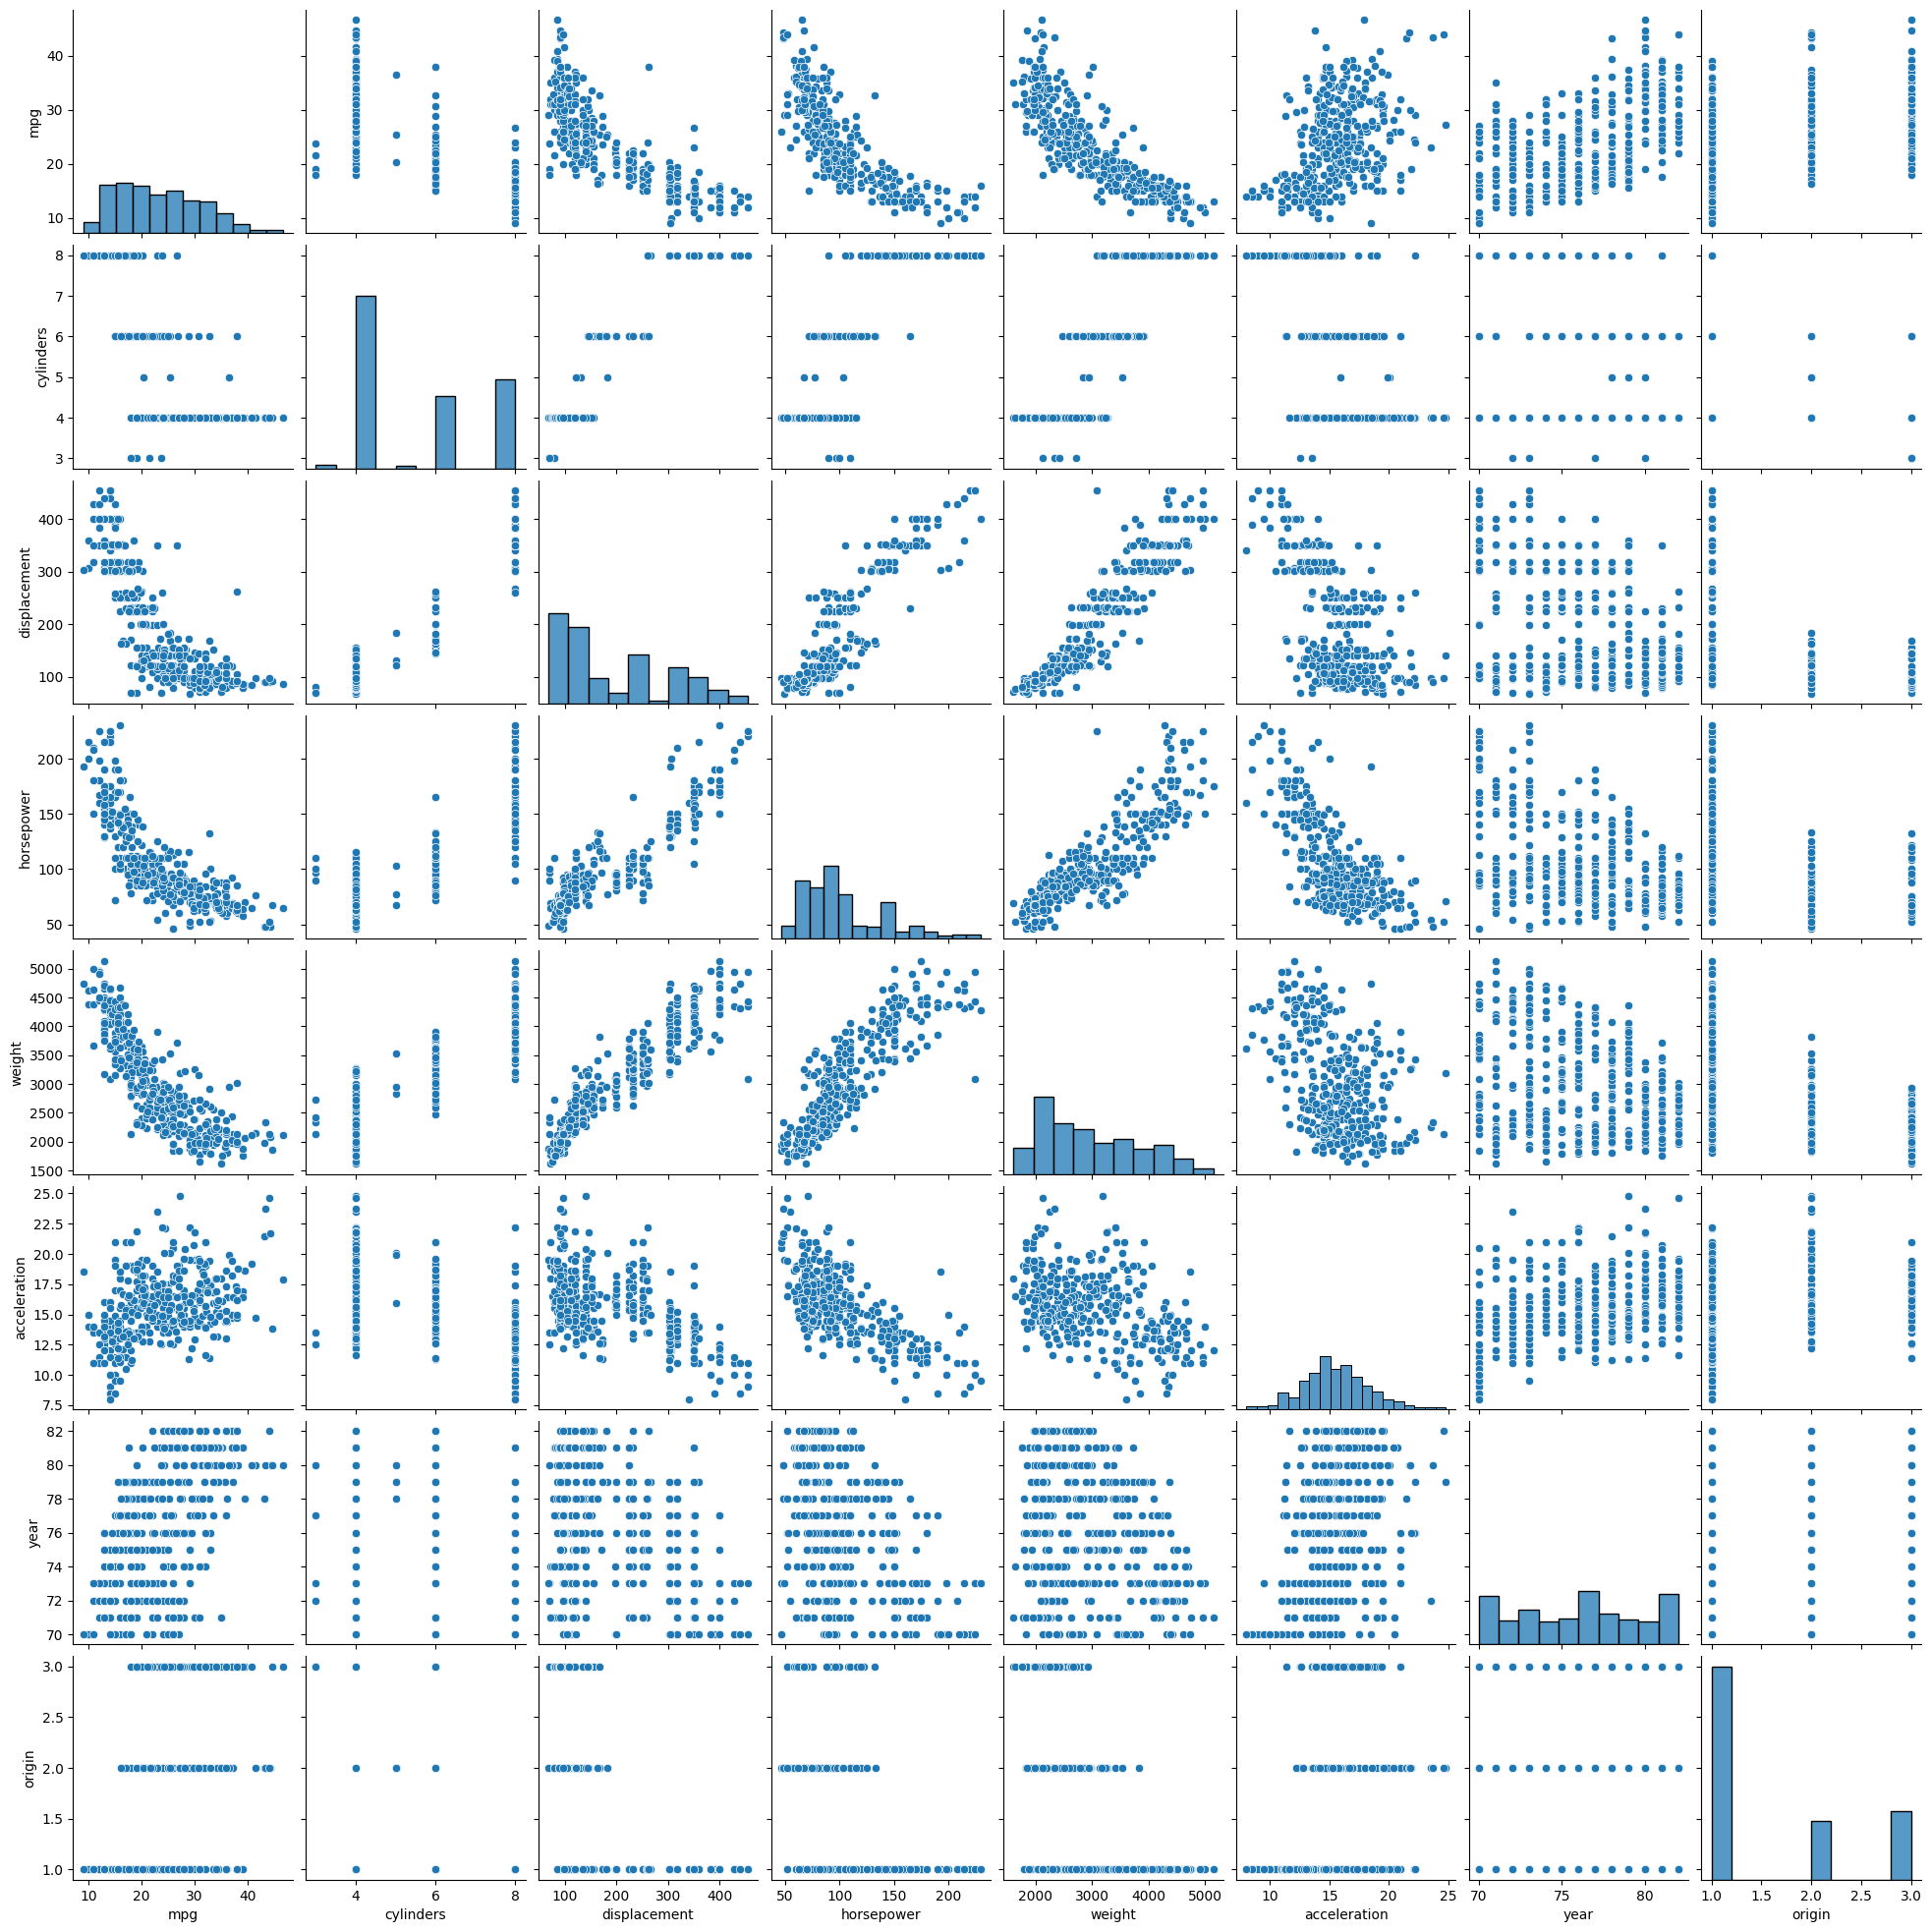

In [43]:
import seaborn as sns
sns.pairplot(Data)

In [54]:
vals=[VIF(Data.values,i) for i in range(Data.shape[1])]
vals
for name, vif in zip(Data.columns, vals):
    print(f"{name}: {vif:.2f}")

mpg: 54.33
cylinders: 119.16
displacement: 98.98
horsepower: 68.80
weight: 170.50
acceleration: 69.84
year: 291.20
origin: 8.95


In [55]:
Data.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [ ]:
multdata=Data.columns.drop('mpg')
x=MS(multdata).fit_transform(Data)
y=Data['mpg']
model=sm.OLS(y,x)
results=model.fit()
summarize(results)
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Thu, 21 May 2026   Prob (F-statistic):          2.04e-139
Time:                        08:18:53   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:

Rsquare=results.rsquared
RESE=np.sqrt(results.scale)

print(f"R Squared={Rsquare} and Residual Standard Error={RESE}")

R Squared=0.8214780764810599 and Residual Standard Error=3.327682396406638


Text(0.5, 1.0, 'Residuals vs Fitted')

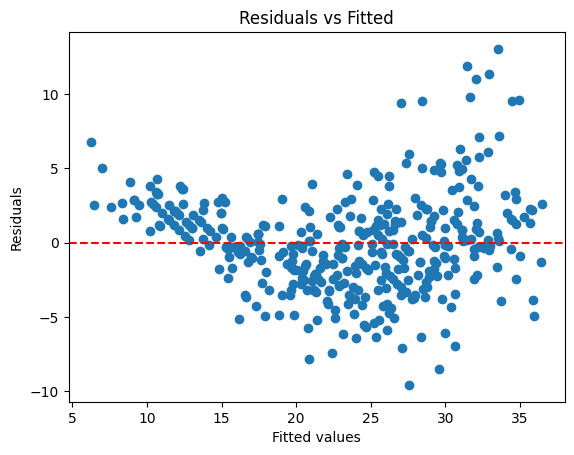

In [ ]:


fig,ax=subplots()
x=results.fittedvalues
y=results.resid
ax.scatter(x,y)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')

In [72]:
x=MS(multdata.to_list()+[('horsepower','weight'),('horsepower','year')]).fit_transform(Data)
y=Data['mpg']
model=sm.OLS(y,x)
results=model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     290.5
Date:                Thu, 21 May 2026   Prob (F-statistic):          7.25e-165
Time:                        16:07:56   Log-Likelihood:                -957.45
No. Observations:                 392   AIC:                             1935.
Df Residuals:                     382   BIC:                             1975.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept           -53.3448     10.836     -4.923      0.000     -74.651     -32.038
cylinders             0.2444      0.281      0.869      0.385      -0.309       0.798
displacement         -0.0006      0.007     -0.094      0.925      -0.014       0.012
horsepower            0.3493      0.105      3.325      0.001       0.143       0.556
weight               -0.0094      0.001    -12.278      0.000      -0.011      -0.008
acceleration         -0.1248      0.085     -1.461      0.145      -0.293       0.043
year                  1.4658      0.130     11.244      0.000       1.209       1.722
origin                0.7995      0.242      3.307      0.001       0.324       1.275
horsepower:weight  4.348e-05   5.44e-06      7.988      0.000    3.28e-05    5.42e-05
horsepower:year      -0.0074      0.001     -5.662      0.000      -0.010      -0.005
==============================================================================
Omnibus:                       36.337   Durbin-Watson:                   1.572
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               67.786
Skew:                           0.552   Prob(JB):                     1.91e-15
Kurtosis:                       4.713   Cond. No.                     3.08e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.08e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [79]:
# 10. This question should be answered using the Carseats data set.
# a) Fit a multiple regression model to predict Sales using Price, Urban, and US.

car=load_data("Carseats")
car.columns
cardata=['Price','Urban','US']
x=MS(cardata).fit_transform(car)
y=car['Sales']
model=sm.OLS(y,x)
results=model.fit()
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Thu, 21 May 2026   Prob (F-statistic):           2.39e-23
Time:                        16:22:12   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0435      0.651     20.036      0.000      11.764      14.323
Price         -0.0545      0.005    -10.389      0.000      -0.065      -0.044
Urban[Yes]    -0.0219      0.272     -0.081      0.936      -0.556       0.512
US[Yes]        1.2006      0.259      4.635      0.000       0.691       1.710
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.758
Skew:                           0.093   Prob(JB):                        0.684
Kurtosis:                       2.897   Cond. No.                         628.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# On the basis of your response to the previous question, fit a
# smaller model that only uses the predictors for which there is
# evidence of association with the outcome.
# How well do the models in (a) and (e) fit the data?

cardata2=['Price','US']
x=MS(cardata2).fit_transform(car)
y=car['Sales']
model=sm.OLS(y,x)
results=model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Thu, 21 May 2026   Prob (F-statistic):           2.66e-24
Time:                        16:33:20   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0308      0.631     20.652      0.000      11.790      14.271
Price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
US[Yes]        1.1996      0.258      4.641      0.000       0.692       1.708
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Using the model from (e), obtain 95 % confidence intervals for
# the coefficient(s).

results.conf_int(alpha=.05)

,0,1
intercept,11.79032,14.271265
Price,-0.06476,-0.044195
US[Yes],0.69152,1.707766


In [ ]:
# 11 In this problem we will investigate the t-statistic for the null hypothesis H0 : β = 0 in simple linear regression without an intercept. To
# begin, we generate a predictor x and a response y as follows.
# > set.seed(1)
# > x <- rnorm(100)
# > y <- 2 * x + rnorm(100)

In [ ]:
# 11 (a) Perform a simple linear regression of y onto x, without an intercept. Report the coefficient estimate βˆ, the standard error of
# this coefficient estimate, and the t-statistic and p-value associated with the null hypothesis H0 : β = 0. Comment on these
# results. (You can perform regression without an intercept using
# the command lm(y∼x+0).)

rng = np.random.default_rng(seed=1)

x = rng.normal(loc=0.0, scale=1.0, size=100)
y = 2 * x + rng.normal(loc=0.0, scale=1.0, size=100)

model=sm.OLS(y,x)
results=model.fit()
#results.summary()

print(f"The Coefficient Estimate is {results.params}, the Standard Error is {results.bse}, the t-statistic is {results.tvalues}, and the p-value is {results.pvalues}")



The Coefficient Estimate is [1.97624238], the Standard Error is [0.11694837], the t-statistic is [16.89841706], and the p-value is [6.23154601e-31]


In [ ]:
#11 (b) Now perform a simple linear regression of x onto y without an
# intercept, and report the coefficient estimate, its standard error,
# and the corresponding t-statistic and p-values associated with
# the null hypothesis H0 : β = 0. Comment on these results.

model=sm.OLS(x,y)
results2=model.fit()
print(f"The Coefficient Estimate is {results2.params}, the Standard Error is {results2.bse}, the t-statistic is {results2.tvalues}, and the p-value is {results2.pvalues}")

The Coefficient Estimate is [0.37574368], the Standard Error is [0.02223544], the t-statistic is [16.89841706], and the p-value is [6.23154601e-31]


In [100]:
# 13. In this exercise you will create some simulated data and will fit simple
# linear regression models to it. Make sure to use set.seed(1) prior to
# starting part (a) to ensure consistent results.

# (a) Using the rnorm() function, create a vector, x, containing 100
# observations drawn from a N(0, 1) distribution. This represents
# a feature, X.

# simulating data
rng = np.random.default_rng(seed=1)
# getting the desired shape
x = rng.normal(loc=0.0, scale=1.0, size=100)

# Using the rnorm() function, create a vector, eps, containing 100
# observations drawn from a N(0, 0.25) distribution—a normal
# distribution with mean zero and variance 0.25.

# Getting desired shape - variance 0.25 (scale = sqrt(0.25) = 0.5)
eps=rng.normal(loc=0.0, scale=.5, size=100)


In [ ]:
# 13 (c) Using x and eps, generate a vector y according to the model
# Y = −1+0.5X + ϵ. (3.39)
# What is the length of the vector y? What are the values of β0
# and β1 in this linear model?

y=-1+.5*x+eps
print(f"The length of y is {len(y)}, and the B0 is -1 and B1 is .5")

The length of y is 100, and the B0 is -1 and B1 is .5


Text(0, 0.5, 'Y Values')

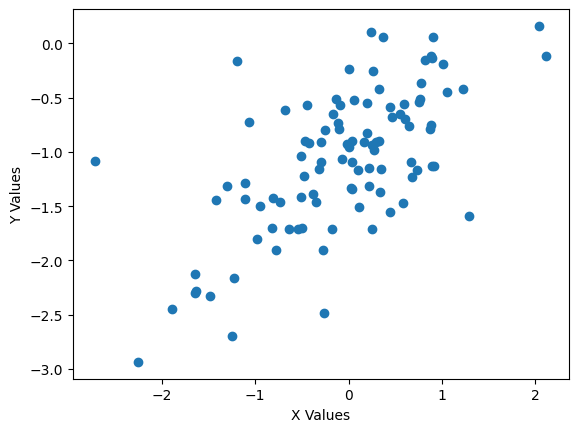

In [ ]:
# 13 (d) Create a scatterplot displaying the relationship between x and
# y. Comment on what you observe.

fig,ax=subplots()
ax.scatter(x,y)
ax.set_xlabel("X Values")
ax.set_ylabel("Y Values")
# Observations: Looks like an overall positive linear relationship, not too much spread

In [ ]:
# 13 (e) Fit a least squares linear model to predict y using x. Comment
# on the model obtained. How do βˆ0 and βˆ1 compare to β0 and
# β1?
#adding intercept
df=pd.DataFrame({'X':x})
design=MS(['X']).fit_transform(df)
model=sm.OLS(y,design)
results=model.fit()
#results.summary()
#results.params
print(f"The B0 predicted is {results.params['intercept']} and the B1 predicted is {results.params['X']}")

# the precitions are really good, -1 versus predicted -1.03 and .5 versus predicted .48. The difference is due to the error eps - normal random noise

The B0 predicted is -1.0380127774981607 and the B1 predicted is 0.48429101457751783


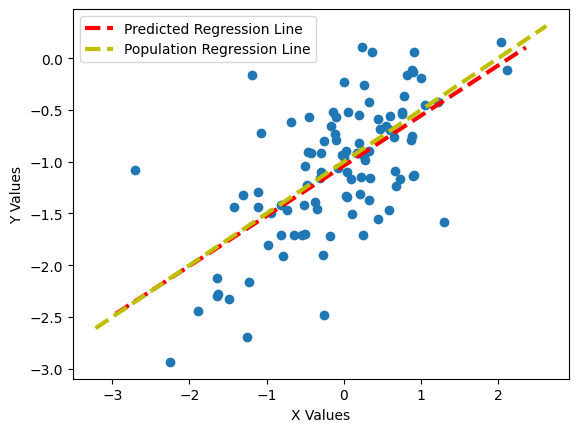

In [ ]:
# 13 (f) Display the least squares line on the scatterplot obtained in (d).
# Draw the population regression line on the plot, in a different
# color. Use the legend() command to create an appropriate legend.

fig,ax=subplots()
ax.scatter(x,y)
ax.set_xlabel("X Values")
ax.set_ylabel("Y Values")

abline(ax,
       results.params['intercept'],
       results.params['X'],
       'r--',
       linewidth=3,
       label="Predicted Regression Line")
abline(ax, 
       -1, 
       .5, 
       'y--', 
       linewidth=3, 
       label='Population Regression Line')
ax.legend()


In [118]:
# 14. This problem focuses on the collinearity problem.
# (a) Perform the following commands in R:
# > set.seed(1)
# > x1 <- runif(100)
# > x2 <- 0.5 * x1 + rnorm(100) / 10
# > y <- 2 + 2 * x1 + 0.3 * x2 + rnorm(100)
# The last line corresponds to creating a linear model in which y is
# a function of x1 and x2. Write out the form of the linear model.
# What are the regression coefficients?
rng = np.random.default_rng(1)
# uniform dist
x1 = rng.uniform(0, 1, 100)
x2 = 0.5 * x1 + rng.normal(0, 1, 100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(0, 1, 100)

# rng.normal(0, 1, 100) this is the error term
# coefficients: 2,2,.3




          X1        X2
X1  1.000000  0.824739
X2  0.824739  1.000000


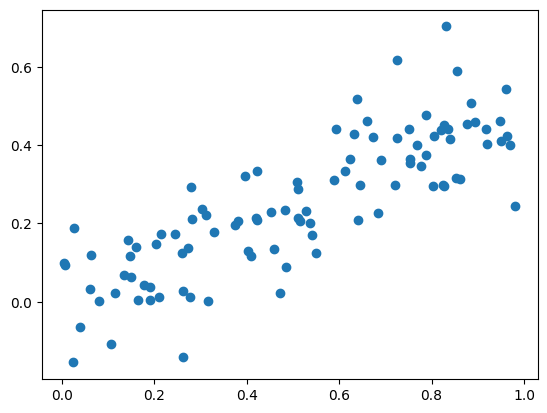

In [ ]:
# 14 continued What is the correlation between x1 and x2? Create a scatterplot
# displaying the relationship between the variables.
df = pd.DataFrame({'X1': x1, 'X2': x2})
df.corr()

fig,ax=subplots()
ax.scatter(df['X1'],df['X2'])

print(df.corr())

In [138]:
# 14 continued Using this data, fit a least squares regression to predict y using
# x1 and x2. Describe the results obtained. What are βˆ0, βˆ1, and
# βˆ2? How do these relate to the true β0, β1, and β2? Can you
# reject the null hypothesis H0 : β1 = 0? How about the null
# hypothesis H0 : β2 = 0?

# Making into dataframe so MS can be used to add intercept to regression
data=pd.DataFrame({'X1':x1,'X2':x2})
x=MS(['X1','X2']).fit_transform(data)
model=sm.OLS(y,x)
results=model.fit()
results.summary()


# print(f"""Since the P-Value for X1 is {results.pvalues['X1']}, we have significant reason to believe X1 is a powerful predictor and reject the
#       null hypothesis.
#       Since the P-Value for X2 is {results.pvalues['X2']}, we do not have significant reason to believe X2 is a valuable predictor
#       and do not reject the null hypothesis""")

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     23.47
Date:                Sat, 23 May 2026   Prob (F-statistic):           4.86e-09
Time:                        14:06:34   Log-Likelihood:                -133.23
No. Observations:                 100   AIC:                             272.5
Df Residuals:                      97   BIC:                             280.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.7934      0.191      9.399      0.000       1.415       2.172
X1             2.1681      0.574      3.780      0.000       1.030       3.306
X2             0.1075      0.943      0.114      0.909      -1.763       1.978
==============================================================================
Omnibus:                        8.630   Durbin-Watson:                   2.540
Prob(Omnibus):                  0.013   Jarque-Bera (JB):                9.407
Skew:                           0.518   Prob(JB):                      0.00907
Kurtosis:                       4.088   Cond. No.                         13.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [137]:
# 14 (d) Now fit a least squares regression to predict y using only x1.
# Comment on your results. Can you reject the null hypothesis
# H0 : β1 = 0?

x=MS(['X1']).fit_transform(data)
model2=sm.OLS(y,x)
results2=model2.fit()
results2.summary()

# print(f"""Since the P-Value for X1 is {results2.pvalues['X1']}, we have significant reason to believe X1 is a powerful predictor and reject the
#       null hypothesis.""")

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     47.41
Date:                Sat, 23 May 2026   Prob (F-statistic):           5.54e-10
Time:                        14:06:08   Log-Likelihood:                -133.23
No. Observations:                 100   AIC:                             270.5
Df Residuals:                      98   BIC:                             275.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.7927      0.190      9.449      0.000       1.416       2.169
X1             2.2221      0.323      6.885      0.000       1.582       2.862
==============================================================================
Omnibus:                        8.658   Durbin-Watson:                   2.539
Prob(Omnibus):                  0.013   Jarque-Bera (JB):                9.469
Skew:                           0.518   Prob(JB):                      0.00878
Kurtosis:                       4.096   Cond. No.                         4.46
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
#14  (e) Now fit a least squares regression to predict y using only x2.
# Comment on your results. Can you reject the null hypothesis
# H0 : β1 = 0?
x=MS(['X2']).fit_transform(data)
model3=sm.OLS(y,x)
results3=model3.fit()
results3.summary()

# X2 has a p-value of 0 - in the original due to colineaity X1 had a stronger relationship with Y so X2 did not add anything of 
# significance. When X1 is out it is still a useful predictor.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     28.75
Date:                Sat, 23 May 2026   Prob (F-statistic):           5.48e-07
Time:                        14:08:34   Log-Likelihood:                -140.10
No. Observations:                 100   AIC:                             284.2
Df Residuals:                      98   BIC:                             289.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.1696      0.173     12.505      0.000       1.825       2.514
X2             3.0459      0.568      5.362      0.000       1.919       4.173
==============================================================================
Omnibus:                        6.390   Durbin-Watson:                   2.580
Prob(Omnibus):                  0.041   Jarque-Bera (JB):                5.812
Skew:                           0.515   Prob(JB):                       0.0547
Kurtosis:                       3.579   Cond. No.                         6.09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# SKLEARN Code

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(model.coef_)        # coefficients
print(model.intercept_)   # intercept
print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

from sklearn.metrics import (confusion_matrix, 
                            classification_report,
                            roc_auc_score, 
                            RocCurveDisplay)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Precision, recall, F1 all at once
print(classification_report(y_test, y_pred))

# AUC-ROC
print(roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

# Plot ROC curve
RocCurveDisplay.from_estimator(model, X_test, y_test)